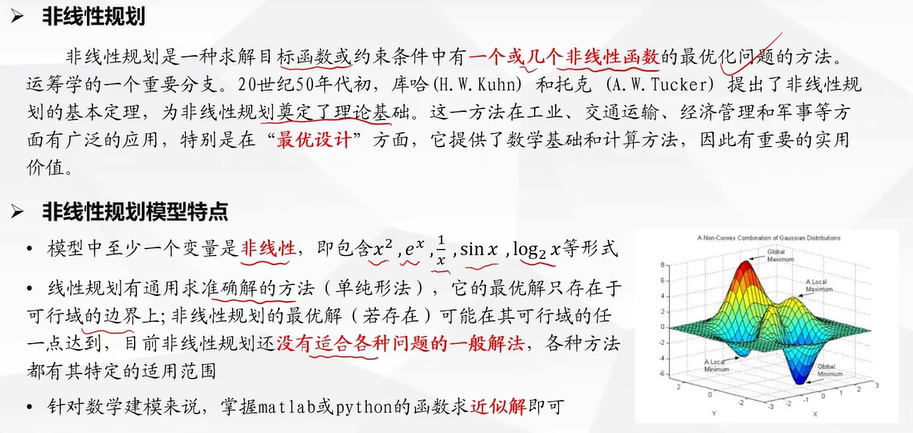

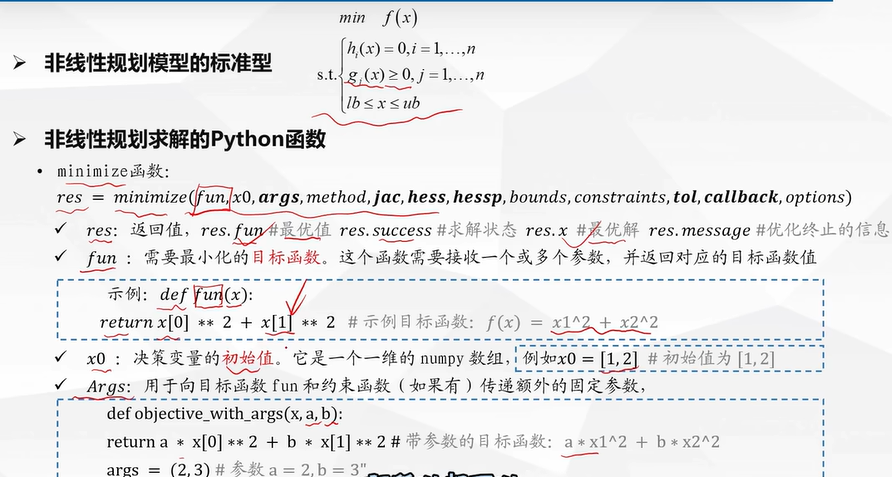

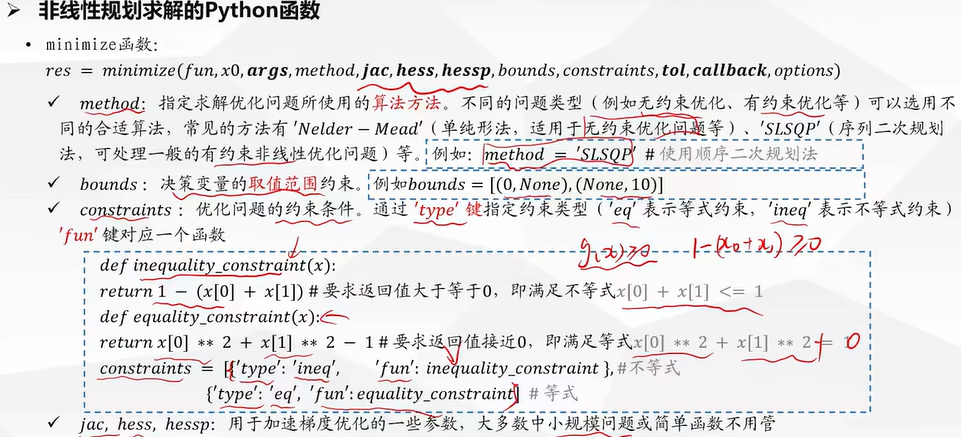

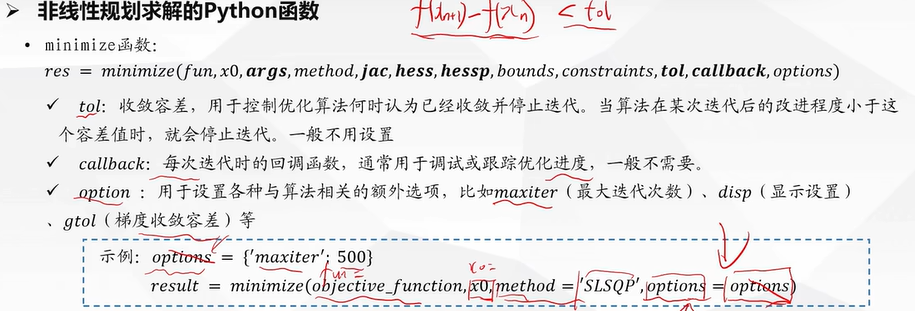

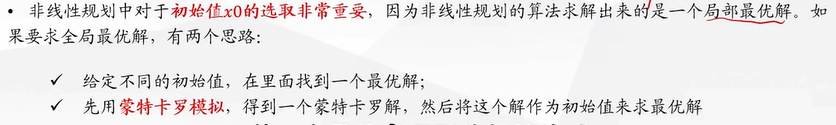

### 典型例题一：

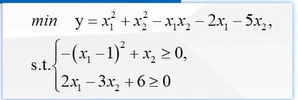

In [1]:
import numpy as np
from scipy.optimize import minimize

# 目标函数，接受一个长度为2的一维数组x（代表两个变量x1和x2），计算并返回目标函数值
def fun1(x):
    return x[0] ** 2 + x[1] ** 2 - x[0] * x[1] - 2 * x[0] - 5 * x[1]

# 第一个非线性约束条件函数，接受变量x，返回对应约束条件的值
def nonlcon1(x):
    return -(x[0] - 1) ** 2 + x[1]

# 第二个非线性约束条件函数，接受变量x，返回对应约束条件的值
def nonlcon2(x):
    return 2 * x[0] - 3 * x[1] + 6

# 初始值设定，设置为一个二维的numpy数组，初始值为[0, 0]
x0 = np.array([0, 0])


In [2]:
# 使用默认算法（内点法类似的算法，在scipy中会根据情况选择合适的）求解
res = minimize(fun1, x0,
               constraints=({'type': 'ineq', 'fun': nonlcon1},
                           {'type': 'ineq', 'fun': nonlcon2}),
               bounds=None, tol=None, options=None, args=())

print("默认算法（类似内点法等情况）求解结果：")
print("最优解：", res.x)
print("最优值：", res.fun)


默认算法（类似内点法等情况）求解结果：
最优解： [2.99999994 3.99999996]
最优值： -12.999999999999998


In [3]:
# 使用SQP算法（序列二次规划法）求解
res_sqp = minimize(fun1, x0, method='SLSQP',
                   constraints=({'type': 'ineq', 'fun': nonlcon1},
                               {'type': 'ineq', 'fun': nonlcon2}),
                   bounds=None, tol=None, options=None, args=())

print("SQP算法（序列二次规划法）求解结果：")
print("最优解：", res_sqp.x)
print("最优值：", res_sqp.fun)

SQP算法（序列二次规划法）求解结果：
最优解： [2.99999994 3.99999996]
最优值： -12.999999999999998


In [6]:

import numpy as np

# 蒙特卡罗方法寻找初始值
n = 10000000  # 随机采样次数

# 生成在 [-100, 100] 区间内均匀分布的随机数
x1 = np.random.uniform(-100, 100, size=n)
x2 = np.random.uniform(-100, 100, size=n)

fmin = float('inf')  # 初始化最小目标函数值
x0 = None            # 记录最优初始点

for i in range(n):
    x = np.array([x1[i], x2[i]])
    
    # 判断是否满足约束条件（非线性不等式约束）
    if nonlcon1(x) >= 0 and nonlcon2(x) >= 0:
        result = fun1(x)
        if result < fmin:
            fmin = result
            x0 = x

print("蒙特卡罗选取的初始值为：", x0)

蒙特卡罗选取的初始值为： [2.92620569 3.88986278]


In [7]:
# 使用拟合的初始值再次进行优化
res_final = minimize(fun1, x0, method='SLSQP',
                     constraints=({'type': 'ineq', 'fun': nonlcon1},
                                 {'type': 'ineq', 'fun': nonlcon2}),
                     bounds=None, tol=None, options=None, args=())

print("基于蒙特卡罗初始值的最终求解结果：")
print("最优解：", res_final.x)
print("最优值：", res_final.fun)

基于蒙特卡罗初始值的最终求解结果：
最优解： [3.00000004 4.00000003]
最优值： -12.999999999999996
